## Failure Prediction : Smart School 

<!-- Il s'agit du fichier EDA - Exploratory Data Analysis

C’est la phase où on explore le dataset avant de faire du machine learning
On ne construit pas encore le modèle, on essaie de comprendre les données. -->

## Step 1

   id  age   genre              diplôme  heures_etude  assiduité_classe  \
0   0   21    male     Computer Science          7.91              98.8   
1   1   18  female                  Law          4.95              94.8   
2   2   20  female     Computer Science          4.68              92.6   
3   3   19    male     Computer Science          2.00              49.5   
4   4   23  female  Business Management          7.65              86.9   

  accès_internet  heures_sommeil qualité_sommeil  méthode_etude  \
0            NaN             4.9         average  online videos   
1            yes             4.7            poor     self-study   
2            NaN             5.8            poor       coaching   
3            yes             8.3         average    group study   
4            yes             9.6            good     self-study   

  évaluation_établissement difficulté_examen  score_examen  heures_fête  \
0                      low              easy         75.02            5

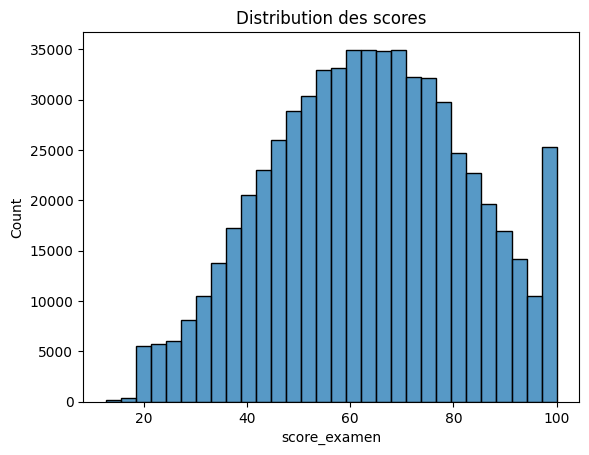

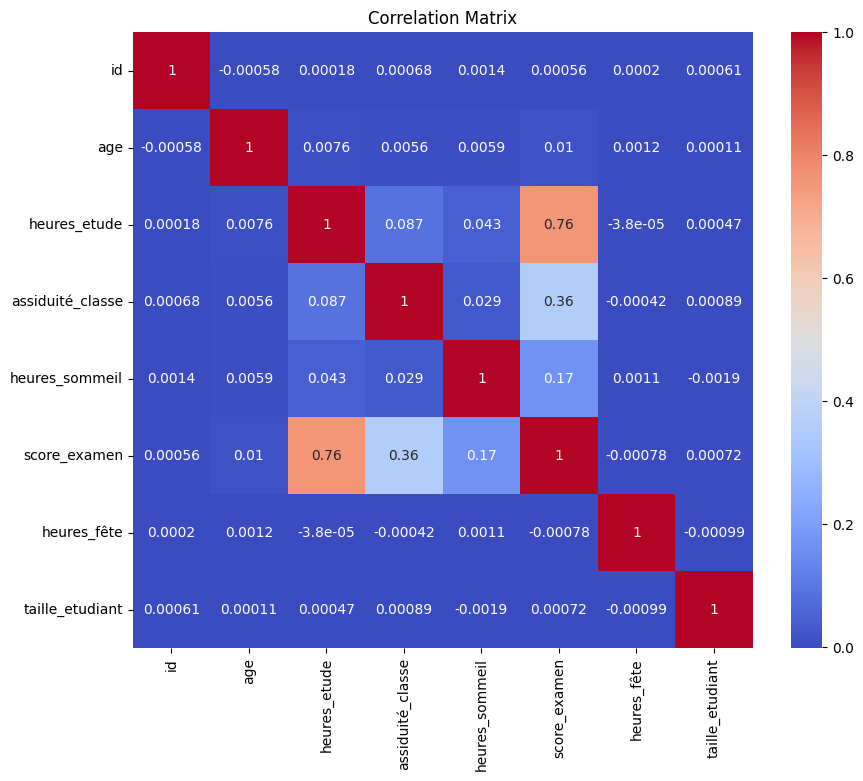

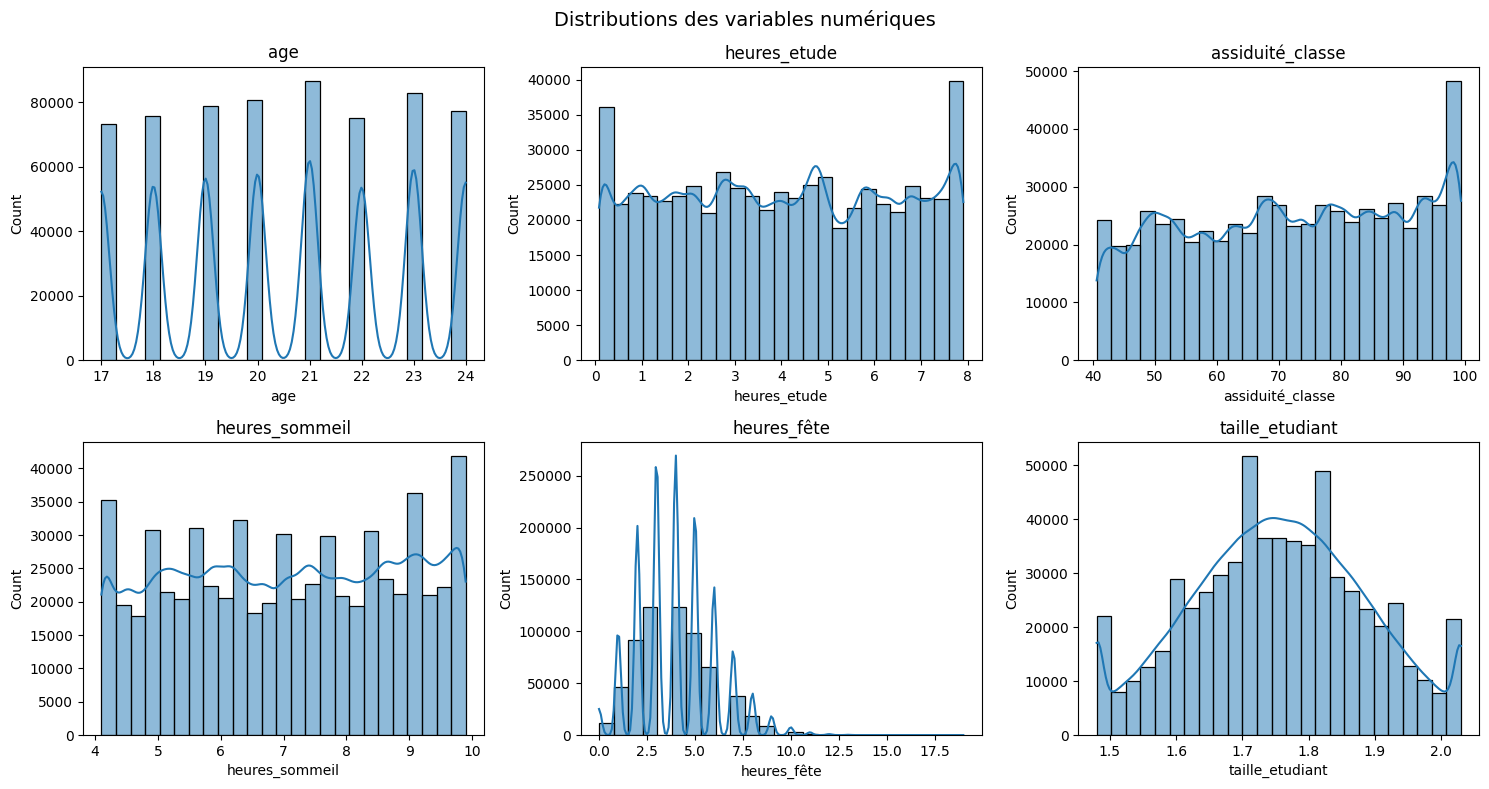

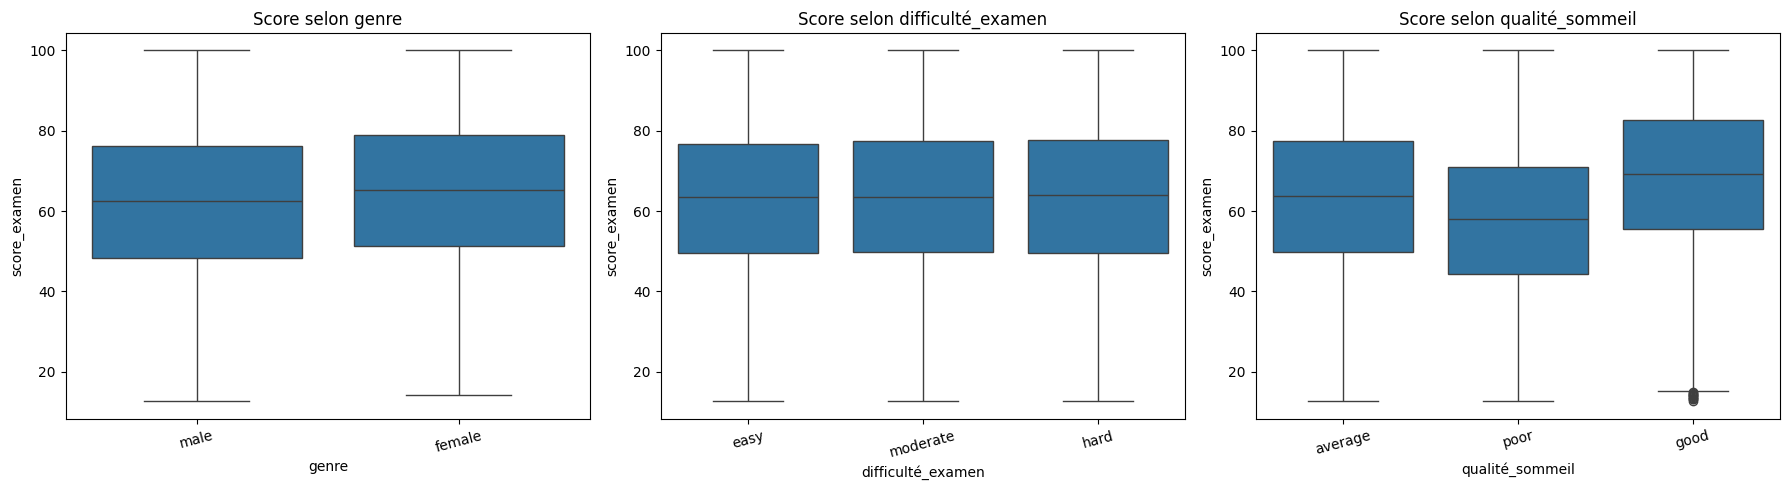

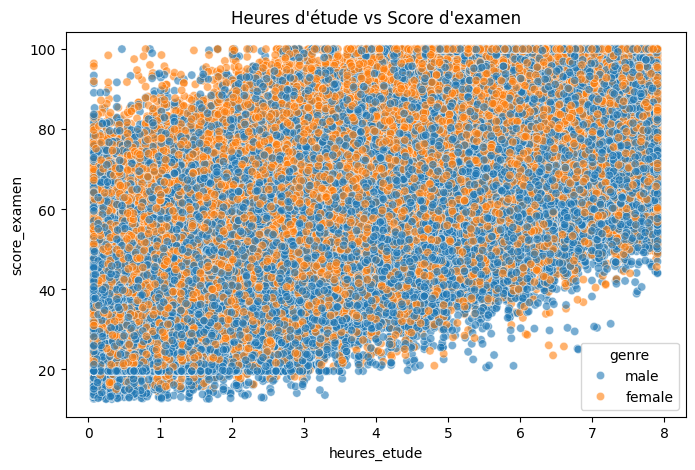

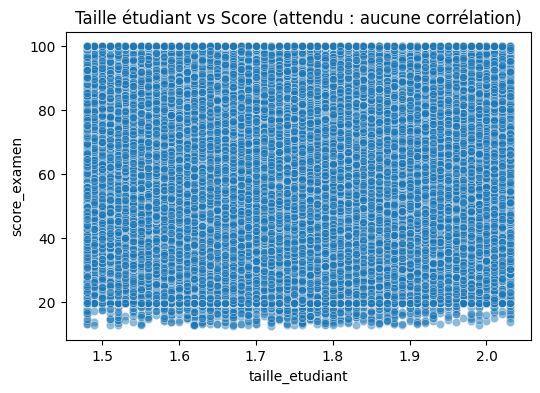

=== Missing values ===
heures_etude      18900
accès_internet    63000
méthode_etude     44100
dtype: int64

Pourcentage manquant :
heures_etude       3.0
accès_internet    10.0
méthode_etude      7.0
dtype: float64


In [2]:
# ── Cellule 1 (existante) ──────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler

csv_path = Path("student_dataset") / "student_failure" / "train.csv"
df = pd.read_csv(csv_path)

print(df.head())
print(df.info())
print(df.describe())

# Distribution du score
plt.figure()
sns.histplot(df["score_examen"], bins=30)
plt.title("Distribution des scores")
plt.show()

# Corrélation
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# ── Cellule 2 (nouvelle) — EDA enrichie ───────────────────────────
# On garde df_raw = données brutes pour les graphes lisibles (labels texte)
df_raw = df.copy()  # df n'est pas encore encodé à ce stade, donc c'est bon

# 1. Distribution de chaque feature numérique
num_cols = ['age', 'heures_etude', 'assiduité_classe', 'heures_sommeil', 'heures_fête', 'taille_etudiant']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(df_raw[col].dropna(), bins=25, ax=ax, kde=True)
    ax.set_title(col)
plt.suptitle("Distributions des variables numériques", fontsize=14)
plt.tight_layout()
plt.show()

# 2. Boxplot score_examen selon variables catégorielles clés
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['genre', 'difficulté_examen', 'qualité_sommeil']):
    sns.boxplot(data=df_raw, x=col, y='score_examen', ax=ax)
    ax.set_title(f'Score selon {col}')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# 3. Scatter heures_etude vs score
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_raw, x='heures_etude', y='score_examen', hue='genre', alpha=0.6)
plt.title("Heures d'étude vs Score d'examen")
plt.show()

# 4. Taille étudiant vs score (vérifier inutilité)
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df_raw, x='taille_etudiant', y='score_examen', alpha=0.5)
plt.title("Taille étudiant vs Score (attendu : aucune corrélation)")
plt.show()

# 5. Analyse des missing values
print("=== Missing values ===")
print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print(f"\nPourcentage manquant :\n{(df_raw.isnull().mean() * 100).round(2)[df_raw.isnull().mean() > 0]}")

## Step 2

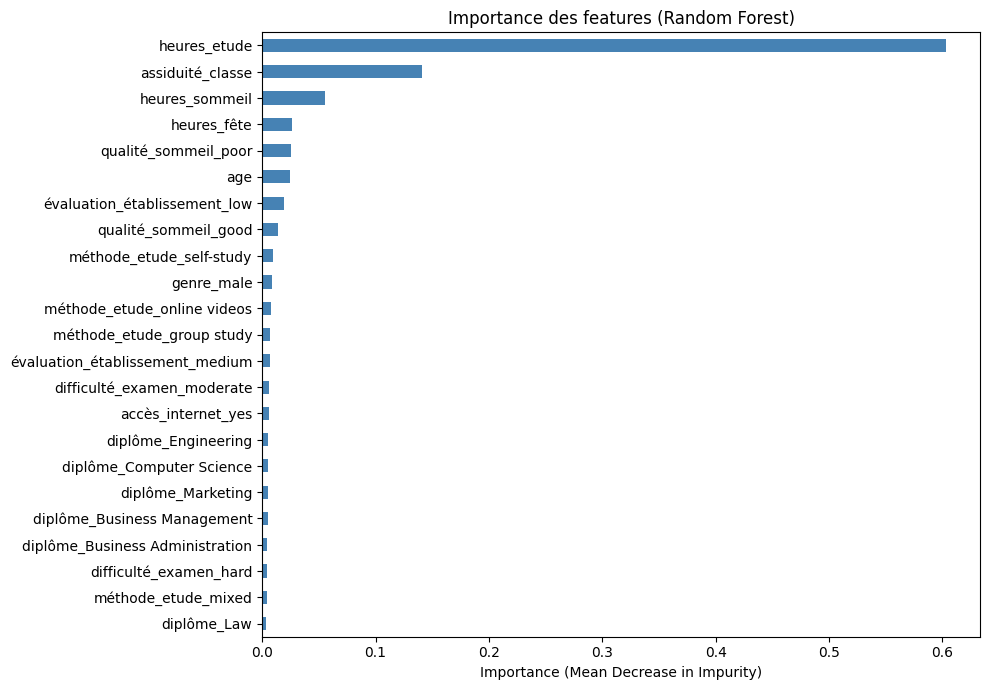


Top 5 features les plus importantes :
heures_etude            0.603142
assiduité_classe        0.141275
heures_sommeil          0.055133
heures_fête             0.025996
qualité_sommeil_poor    0.025186
dtype: float64

Features quasi-nulles (< 0.01) :
diplôme_Law                        0.003736
méthode_etude_mixed                0.004514
difficulté_examen_hard             0.004569
diplôme_Business Administration    0.004577
diplôme_Business Management        0.004840
diplôme_Marketing                  0.005038
diplôme_Computer Science           0.005183
diplôme_Engineering                0.005286
accès_internet_yes                 0.006212
difficulté_examen_moderate         0.006258
évaluation_établissement_medium    0.006895
méthode_etude_group study          0.007083
méthode_etude_online videos        0.008118
genre_male                         0.009051
méthode_etude_self-study           0.009637
dtype: float64


In [3]:
# ── Étape 2 — Feature importance + nettoyage ──────────────────────

# Supprimer taille_etudiant et id (confirmés comme non pertinents)
df = df.drop(columns=['taille_etudiant', 'id'], errors='ignore')

# Encoding (remplace ta ligne get_dummies existante)
df = pd.get_dummies(df, drop_first=True)

# Séparer X et y
X = df.drop("score_examen", axis=1)
y = df["score_examen"]

# Gestion missing values
numeric_cols = X.select_dtypes(include="number").columns
X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Feature importance avec Random Forest (avant split) ──
from sklearn.ensemble import RandomForestRegressor

rf_for_importance = RandomForestRegressor(n_estimators=100, random_state=42)
rf_for_importance.fit(X_scaled, y)

importances = pd.Series(rf_for_importance.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 7))
importances_sorted.plot(kind='barh', color='steelblue')
plt.title("Importance des features (Random Forest)")
plt.xlabel("Importance (Mean Decrease in Impurity)")
plt.tight_layout()
plt.show()

print("\nTop 5 features les plus importantes :")
print(importances.sort_values(ascending=False).head())
print("\nFeatures quasi-nulles (< 0.01) :")
print(importances[importances < 0.01].sort_values())

## Step 3. Split train/val/test + cross-validation

In [9]:
# ── Étape 3 — Split train / val / test + cross-validation ─────────
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression 


# Split 60% train / 20% val / 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42  # 0.25 x 0.80 = 0.20
)

print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(y)*100:.0f}%)")
print(f"Val   : {X_val.shape[0]} samples ({X_val.shape[0]/len(y)*100:.0f}%)")
print(f"Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(y)*100:.0f}%)")

# Cross-validation sur le train (5 folds) pour évaluer la stabilité
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("\n=== Cross-validation (5-fold) sur le train ===")
for name, model in [
    ("Random Forest",    RandomForestRegressor(n_estimators=100, random_state=42)),
    ("Linear Regression", LinearRegression()),
]:
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='neg_root_mean_squared_error')
    rmse_scores = -scores
    print(f"\n{name}")
    print(f"  RMSE par fold : {rmse_scores.round(2)}")
    print(f"  Moyenne : {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")

# # ── Étape 3 — Sous-échantillonnage + Split train / val / test ──────
# from sklearn.model_selection import train_test_split, KFold, cross_val_score
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.linear_model import LinearRegression

# # Sous-échantillonnage : on garde 50 000 lignes (largement suffisant)
# from sklearn.utils import resample
# X_sampled, y_sampled = resample(X_scaled, y,
#                                 n_samples=100000,
#                                 random_state=42)
# print(f"Dataset réduit : {X_sampled.shape[0]} lignes")

# # Split 60% train / 20% val / 20% test
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X_sampled, y_sampled, test_size=0.20, random_state=42
# )
# X_train, X_val, y_train, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.25, random_state=42
# )

# print(f"Train : {X_train.shape[0]} samples ({X_train.shape[0]/len(y_sampled)*100:.0f}%)")
# print(f"Val   : {X_val.shape[0]} samples ({X_val.shape[0]/len(y_sampled)*100:.0f}%)")
# print(f"Test  : {X_test.shape[0]} samples ({X_test.shape[0]/len(y_sampled)*100:.0f}%)")

# # Cross-validation sur le train
# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# print("\n=== Cross-validation (5-fold) sur le train ===")
# for name, model in [
#     ("Random Forest",     RandomForestRegressor(n_estimators=100, random_state=42)),
#     ("Linear Regression", LinearRegression()),
# ]:
#     scores = cross_val_score(model, X_train, y_train,
#                              cv=kf, scoring='neg_root_mean_squared_error')
#     rmse_scores = -scores
#     print(f"\n{name}")
#     print(f"  RMSE par fold : {rmse_scores.round(2)}")
#     print(f"  Moyenne : {rmse_scores.mean():.2f} ± {rmse_scores.std():.2f}")

Train : 378000 samples (60%)
Val   : 126000 samples (20%)
Test  : 126000 samples (20%)

=== Cross-validation (5-fold) sur le train ===

Random Forest
  RMSE par fold : [9.72 9.68 9.66 9.68 9.68]
  Moyenne : 9.69 ± 0.02

Linear Regression
  RMSE par fold : [9.4  9.36 9.37 9.37 9.35]
  Moyenne : 9.37 ± 0.02


## Step 4. Entraînement complet de tout les modèles + tableau comparatif 

Baseline RMSE : 18.90
Linear Regression — Train: 9.37 | Test: 9.37
Random Forest  — Train: 3.62 | Test: 9.68
XGBoost        — Train: 9.10 | Test: 9.32
  Epoch 20/200 — Loss (RMSE): 9.34
  Epoch 40/200 — Loss (RMSE): 9.32
  Epoch 60/200 — Loss (RMSE): 9.30
  Epoch 80/200 — Loss (RMSE): 9.29
  Epoch 100/200 — Loss (RMSE): 9.29
  Epoch 120/200 — Loss (RMSE): 9.28
  Epoch 140/200 — Loss (RMSE): 9.27
  Epoch 160/200 — Loss (RMSE): 9.27
  Epoch 180/200 — Loss (RMSE): 9.26
  Epoch 200/200 — Loss (RMSE): 9.26
Neural Network — Train: 9.25 | Test: 9.45


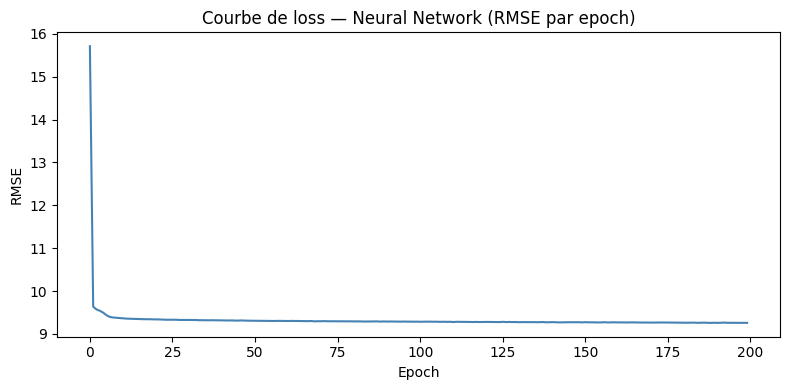


COMPARAISON DES MODÈLES
                   RMSE train RMSE test
Baseline (moyenne)          -      18.9
Linear Regression        9.37      9.37
Random Forest            3.62      9.68
XGBoost                   9.1      9.32
Neural Network           9.25      9.45


In [10]:
# ── Étape 4 — Entraînement complet + comparaison des modèles ──────
import torch
import torch.nn as nn
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from torch.utils.data import TensorDataset, DataLoader

results = {}

# ── Baseline ──
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
results["Baseline (moyenne)"] = {"RMSE train": "-", "RMSE test": round(baseline_rmse, 2)}
print(f"Baseline RMSE : {baseline_rmse:.2f}")

# ── Linear Regression ──
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_train_rmse = mean_squared_error(y_train, lr.predict(X_train)) ** 0.5
lr_test_rmse  = mean_squared_error(y_test,  lr.predict(X_test))  ** 0.5
results["Linear Regression"] = {"RMSE train": round(lr_train_rmse, 2), "RMSE test": round(lr_test_rmse, 2)}
print(f"Linear Regression — Train: {lr_train_rmse:.2f} | Test: {lr_test_rmse:.2f}")

# ── Random Forest ──
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_train_rmse = mean_squared_error(y_train, rf.predict(X_train)) ** 0.5
rf_test_rmse  = mean_squared_error(y_test,  rf.predict(X_test))  ** 0.5
results["Random Forest"] = {"RMSE train": round(rf_train_rmse, 2), "RMSE test": round(rf_test_rmse, 2)}
print(f"Random Forest  — Train: {rf_train_rmse:.2f} | Test: {rf_test_rmse:.2f}")

# ── XGBoost (avant le NN pour économiser la RAM) ──
xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0, n_jobs=1)
xgb.fit(X_train, y_train)
xgb_train_rmse = mean_squared_error(y_train, xgb.predict(X_train)) ** 0.5
xgb_test_rmse  = mean_squared_error(y_test,  xgb.predict(X_test))  ** 0.5
results["XGBoost"] = {"RMSE train": round(xgb_train_rmse, 2), "RMSE test": round(xgb_test_rmse, 2)}
print(f"XGBoost        — Train: {xgb_train_rmse:.2f} | Test: {xgb_test_rmse:.2f}")

# ── Neural Network avec mini-batches ──
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.float32).unsqueeze(1)

nn_model = nn.Sequential(
    nn.Linear(X_train_t.shape[1], 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)
loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001)

dataset_train = TensorDataset(X_train_t, y_train_t)
loader = DataLoader(dataset_train, batch_size=512, shuffle=True)

epochs = 200
train_losses = []

for epoch in range(epochs):
    nn_model.train()
    batch_losses = []
    for X_batch, y_batch in loader:  # ← mini-batches obligatoires
        optimizer.zero_grad()
        preds = nn_model(X_batch)
        loss  = loss_fn(preds, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item() ** 0.5)
    epoch_loss = np.mean(batch_losses)
    train_losses.append(epoch_loss)
    if (epoch + 1) % 20 == 0:
        print(f"  Epoch {epoch+1}/{epochs} — Loss (RMSE): {epoch_loss:.2f}")

nn_model.eval()
with torch.no_grad():
    nn_train_rmse = (loss_fn(nn_model(X_train_t), y_train_t).item()) ** 0.5
    nn_test_rmse  = (loss_fn(nn_model(X_test_t),  y_test_t).item())  ** 0.5
results["Neural Network"] = {"RMSE train": round(nn_train_rmse, 2), "RMSE test": round(nn_test_rmse, 2)}
print(f"Neural Network — Train: {nn_train_rmse:.2f} | Test: {nn_test_rmse:.2f}")

# ── Courbe de loss ──
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.title("Courbe de loss — Neural Network (RMSE par epoch)")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

# ── Tableau récapitulatif ──
print("\n" + "="*50)
print("COMPARAISON DES MODÈLES")
print("="*50)
df_results = pd.DataFrame(results).T
print(df_results.to_string())

## Step 5. GridSearch 

In [11]:
# ── Étape B — Hyperparameter tuning (GridSearch Random Forest) ────
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

param_grid = {
    'max_depth':        [5, 10, 20],
    'min_samples_leaf': [5, 20, 50],
    'n_estimators':     [100]      # fixé à 100 pour économiser RAM
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Meilleurs paramètres :", grid_search.best_params_)
print(f"Meilleur RMSE CV    : {-grid_search.best_score_:.2f}")

best_rf = grid_search.best_estimator_
best_rf_train = mean_squared_error(y_train, best_rf.predict(X_train)) ** 0.5
best_rf_test  = mean_squared_error(y_test,  best_rf.predict(X_test))  ** 0.5
print(f"\nRandom Forest tuné — Train: {best_rf_train:.2f} | Test: {best_rf_test:.2f}")
print(f"Avant tuning       — Train: 3.62          | Test: 9.68")
print(f"Amélioration test  : {9.68 - best_rf_test:.2f} points de RMSE")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Meilleurs paramètres : {'max_depth': 20, 'min_samples_leaf': 20, 'n_estimators': 100}
Meilleur RMSE CV    : 9.57

Random Forest tuné — Train: 8.67 | Test: 9.53
Avant tuning       — Train: 3.62          | Test: 9.68
Amélioration test  : 0.15 points de RMSE


## Step 6. Analyse de l'overfitting / underfitting 

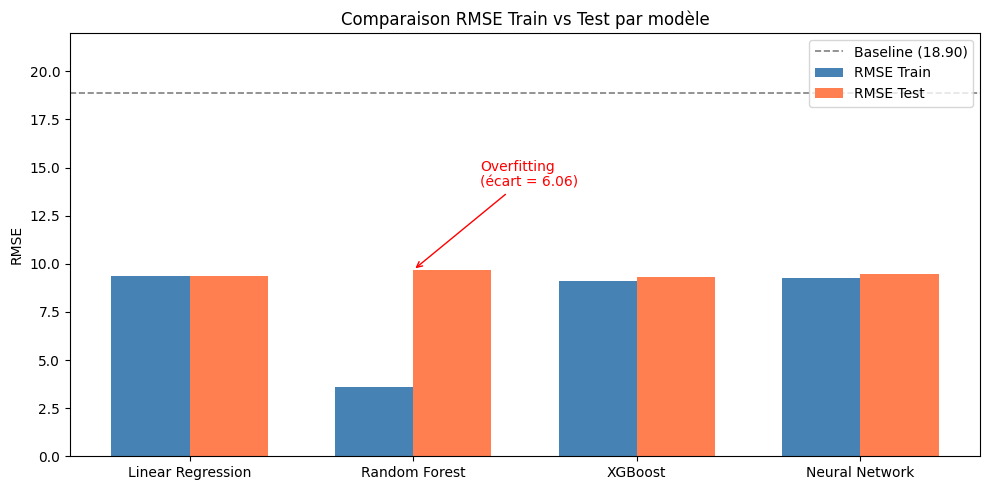

=== Analyse overfitting / underfitting ===

Linear Regression    | Train: 9.37 | Test: 9.37 | Gap: 0.00 | ✅ Bon équilibre
Random Forest        | Train: 3.62 | Test: 9.68 | Gap: 6.06 | ⚠️  Overfitting (gap significatif)
XGBoost              | Train: 9.10 | Test: 9.32 | Gap: 0.21 | ✅ Bon équilibre
Neural Network       | Train: 9.25 | Test: 9.45 | Gap: 0.19 | ✅ Bon équilibre

Baseline             | Train:   -  | Test: 18.90 | Référence


In [12]:
# ── Step 6 corrigé — utilise les vraies variables ──────────────────
models_names = ["Linear Regression", "Random Forest", "XGBoost", "Neural Network"]
rmse_train   = [lr_train_rmse, rf_train_rmse, xgb_train_rmse, nn_train_rmse]
rmse_test    = [lr_test_rmse,  rf_test_rmse,  xgb_test_rmse,  nn_test_rmse]

x = np.arange(len(models_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, rmse_train, width, label='RMSE Train', color='steelblue')
ax.bar(x + width/2, rmse_test,  width, label='RMSE Test',  color='coral')

ax.axhline(y=baseline_rmse, color='gray', linestyle='--',
           linewidth=1.2, label=f'Baseline ({baseline_rmse:.2f})')

ax.set_ylabel('RMSE')
ax.set_title('Comparaison RMSE Train vs Test par modèle')
ax.set_xticks(x)
ax.set_xticklabels(models_names)
ax.legend()
ax.set_ylim(0, 22)

ax.annotate('Overfitting\n(écart = 6.06)', xy=(1, rf_test_rmse),
            xytext=(1.3, 14),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=10)

plt.tight_layout()
plt.show()

print("=== Analyse overfitting / underfitting ===\n")
for name, tr, te in zip(models_names, rmse_train, rmse_test):
    gap = te - tr
    if gap > 2:
        verdict = "⚠️  Overfitting (gap significatif)"
    elif tr > 15:
        verdict = "❌ Underfitting"
    else:
        verdict = "✅ Bon équilibre"
    print(f"{name:20s} | Train: {tr:.2f} | Test: {te:.2f} | Gap: {gap:.2f} | {verdict}")

print(f"\n{'Baseline':20s} | Train:   -  | Test: {baseline_rmse:.2f} | Référence")